# 🚢 Titanic Survival Prediction

## Machine Learning from Disaster

### 📖 Project Overview

The Titanic disaster is one of the most well-known shipwrecks in history.

This project predicts whether a passenger survived the Titanic disaster using various Machine Learning algorithms.

---

## Objectives

- Explore the dataset
- Clean missing values
- Perform feature engineering
- Train multiple ML models
- Compare their performances
- Select the best model
- Generate Kaggle submission

---

## Algorithms Used

- Logistic Regression
- SGD Classifier
- Decision Tree
- Random Forest

---

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC
- Confusion Matrix

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve

import os

In [2]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
675,676,0,3,"Edvardsson, Mr. Gustaf Hjalmar",male,18.0,0,0,349912,7.7750,NaN,S
834,835,0,3,"Allum, Mr. Owen George",male,18.0,0,0,2223,8.3000,NaN,S
137,138,0,1,"Futrelle, Mr. Jacques Heath",male,37.0,1,0,113803,53.1000,C123,S
842,843,1,1,"Serepeca, Miss. Augusta",female,30.0,0,0,113798,31.0000,NaN,C
805,806,0,3,"Johansson, Mr. Karl Johan",male,31.0,0,0,347063,7.7750,NaN,S
468,469,0,3,"Scanlan, Mr. James",male,NaN,0,0,36209,7.7250,NaN,Q
770,771,0,3,"Lievens, Mr. Rene Aime",male,24.0,0,0,345781,9.5000,NaN,S
133,134,1,2,"Weisz, Mrs. Leopold (Mathilde Francoise Pede)",female,29.0,1,0,228414,26.0000,NaN,S
852,853,0,3,"Boulos, Miss. Nourelain",female,9.0,1,1,2678,15.2458,NaN,C


In [5]:
train.shape

(891, 12)

In [6]:
test.shape

(418, 11)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [9]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**EDA**

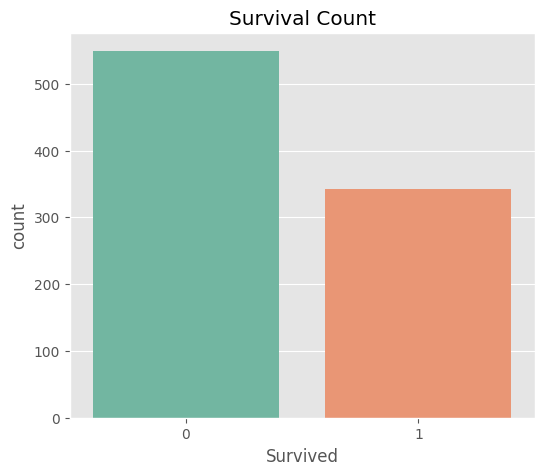

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=train,
    x="Survived",
    palette="Set2"
)

plt.title("Survival Count")
plt.show()

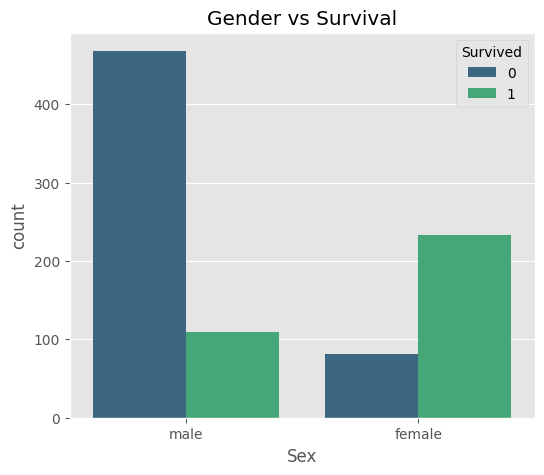

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=train,
    x="Sex",
    hue="Survived",
    palette="viridis"
)

plt.title("Gender vs Survival")
plt.show()

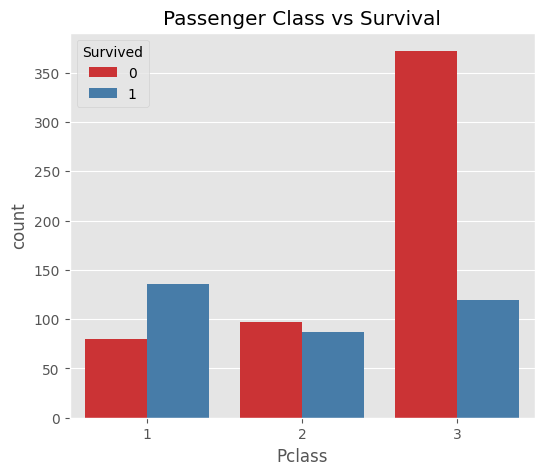

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=train,
    x="Pclass",
    hue="Survived",
    palette="Set1"
)

plt.title("Passenger Class vs Survival")
plt.show()

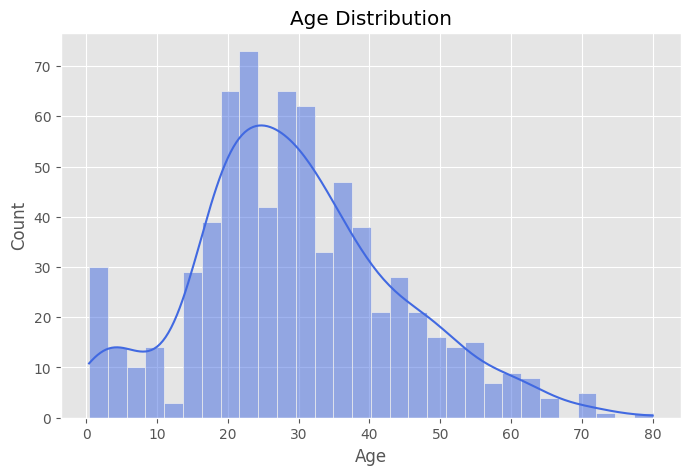

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["Age"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Age Distribution")
plt.show()

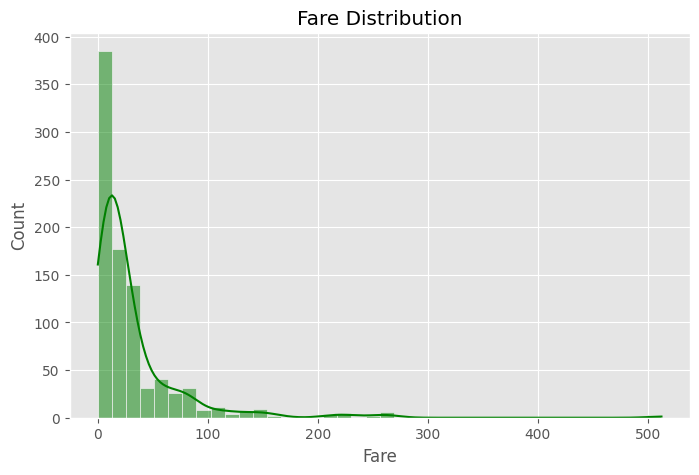

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["Fare"],
    bins=40,
    kde=True,
    color="green"
)

plt.title("Fare Distribution")
plt.show()

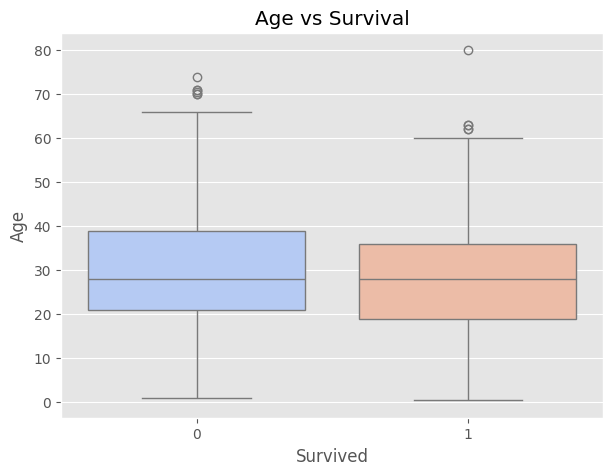

In [15]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=train,
    x="Survived",
    y="Age",
    palette="coolwarm"
)

plt.title("Age vs Survival")
plt.show()

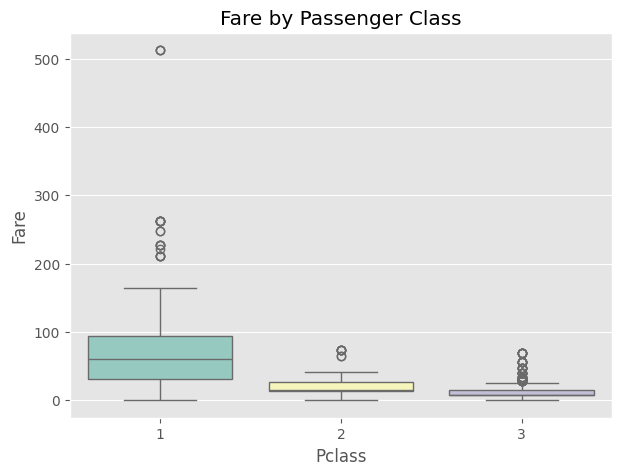

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=train,
    x="Pclass",
    y="Fare",
    palette="Set3"
)

plt.title("Fare by Passenger Class")
plt.show()

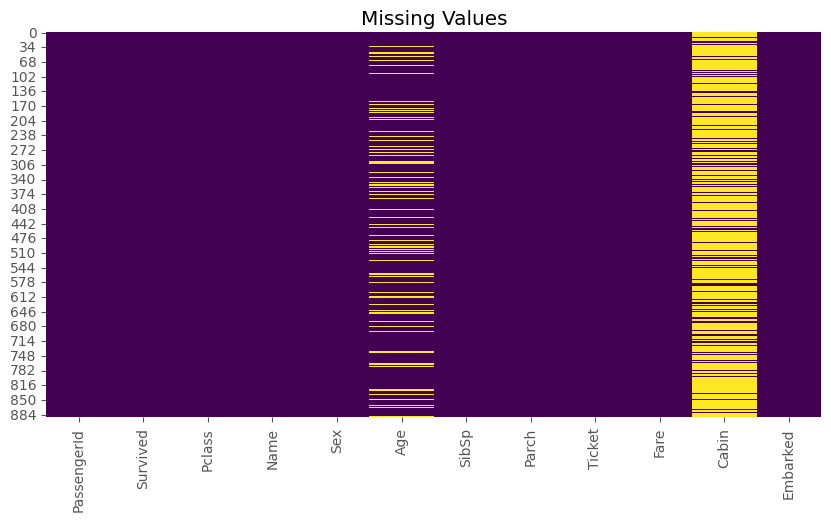

In [17]:
plt.figure(figsize=(10,5))

sns.heatmap(
    train.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values")
plt.show()

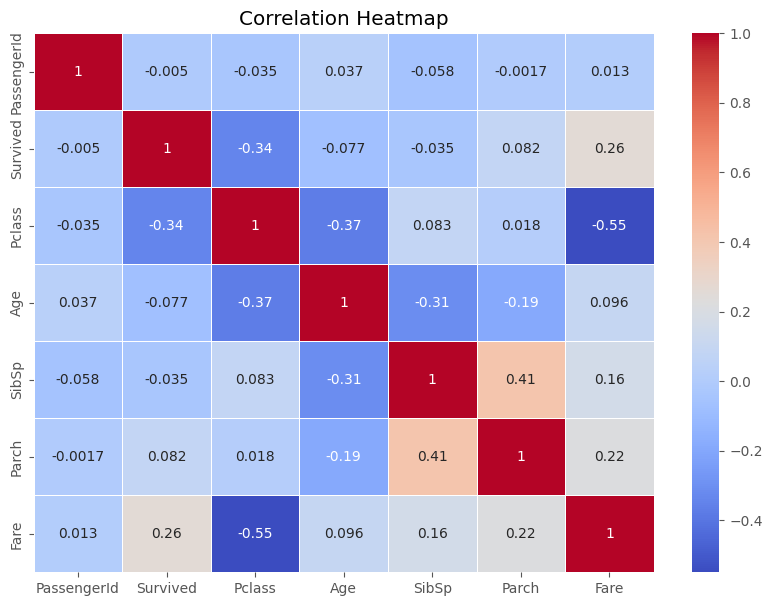

In [18]:
plt.figure(figsize=(10,7))

corr = train.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [19]:
train.groupby("Sex")["Survived"].mean().sort_values(ascending=False)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

# 🧹 Data Cleaning & Feature Engineering

In this section we will:

- Handle missing values
- Create new informative features
- Encode categorical variables
- Prepare the dataset for Machine Learning

In [20]:
test_ids = test["PassengerId"]

In [21]:
full_data = pd.concat([train, test], axis=0, ignore_index=True)

print(full_data.shape)

(1309, 12)


In [22]:
full_data.isnull().sum().sort_values(ascending=False)

Cabin          1014
Survived        418
Age             263
Embarked          2
Fare              1
Name              0
PassengerId       0
Pclass            0
Parch             0
SibSp             0
Sex               0
Ticket            0
dtype: int64

In [23]:
full_data["Age"] = full_data["Age"].fillna(
    full_data["Age"].median()
)

In [24]:
full_data["Embarked"] = full_data["Embarked"].fillna(
    full_data["Embarked"].mode()[0]
)

In [25]:
full_data["Fare"] = full_data["Fare"].fillna(
    full_data["Fare"].median()
)

In [26]:
full_data["Cabin"] = full_data["Cabin"].fillna("Unknown")

In [27]:
full_data["FamilySize"] = (
    full_data["SibSp"] +
    full_data["Parch"] +
    1
)

In [28]:
full_data["IsAlone"] = (
    full_data["FamilySize"] == 1
).astype(int)

In [29]:
full_data["Title"] = full_data["Name"].str.extract(
    " ([A-Za-z]+)\.",
    expand=False
)

In [30]:
full_data["Title"].value_counts()

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Major         2
Mlle          2
Ms            2
Mme           1
Don           1
Sir           1
Lady          1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

In [31]:
full_data["Title"] = full_data["Title"].replace(
[
'Lady','Countess','Capt','Col',
'Don','Dr','Major','Rev',
'Sir','Jonkheer','Dona'
],
'Rare'
)

full_data["Title"] = full_data["Title"].replace(
'Ms','Miss'
)

full_data["Title"] = full_data["Title"].replace(
'Mlle','Miss'
)

full_data["Title"] = full_data["Title"].replace(
'Mme','Mrs'
)

In [32]:
full_data["Sex"] = LabelEncoder().fit_transform(
    full_data["Sex"]
)

In [33]:
full_data["Embarked"] = LabelEncoder().fit_transform(
    full_data["Embarked"]
)

In [34]:
full_data["Title"] = LabelEncoder().fit_transform(
    full_data["Title"]
)

In [35]:
full_data["CabinKnown"] = (
    full_data["Cabin"] != "Unknown"
).astype(int)

In [36]:
full_data.drop(
[
"PassengerId",
"Name",
"Ticket",
"Cabin"
],
axis=1,
inplace=True
)

In [37]:
train = full_data.iloc[:891].copy()

test = full_data.iloc[891:].copy()

In [38]:
X = train.drop("Survived", axis=1)

y = train["Survived"]

test = test.drop("Survived", axis=1)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (712, 11)
Testing Features  : (179, 11)
Training Labels   : (712,)
Testing Labels    : (179,)


In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

test_scaled = scaler.transform(test)

In [42]:
pd.DataFrame(
    X_train,
    columns=X.columns
).head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,CabinKnown
692,3,1,28.0,0,0,56.4958,2,1,1,2,0
481,2,1,28.0,0,0,0.0000,2,1,1,2,0
527,1,1,28.0,0,0,221.7792,2,1,1,2,1
855,3,0,18.0,0,1,9.3500,2,2,0,3,0
801,2,0,31.0,1,1,26.2500,2,3,0,3,0


# 🤖 Model Training

We will train multiple machine learning algorithms and compare their performance.

In [43]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SGD Classifier": SGDClassifier(loss="log_loss", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

In [44]:
results = []

for name, model in models.items():

    if name == "SGD Classifier":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append([name, acc])

results

[['Logistic Regression', 0.8156424581005587],
 ['SGD Classifier', 0.7541899441340782],
 ['Decision Tree', 0.7653631284916201],
 ['Random Forest', 0.7988826815642458]]

In [45]:
results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

results.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results

,Model,Accuracy
0,Logistic Regression,0.815642
3,Random Forest,0.798883
2,Decision Tree,0.765363
1,SGD Classifier,0.754190


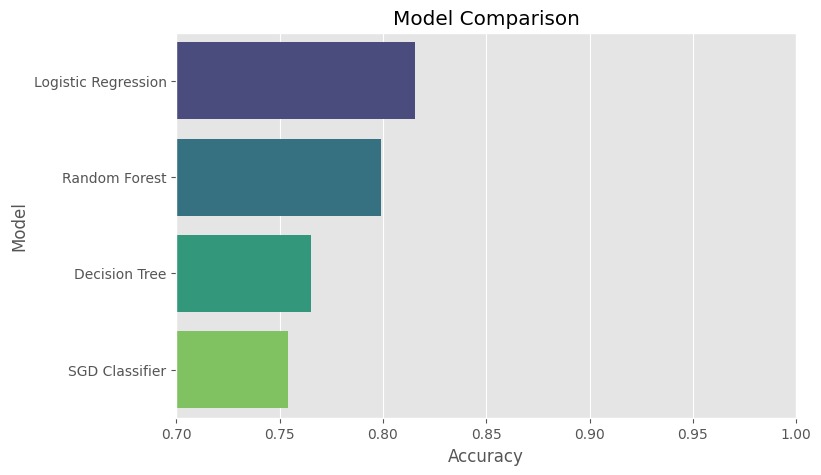

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Comparison")
plt.xlim(0.70,1)

plt.show()

In [47]:
best_model_name = results.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


In [48]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [49]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5
)

print(scores)

[0.79888268 0.78089888 0.84269663 0.76404494 0.83146067]


In [50]:
print("Average Accuracy :", scores.mean())

Average Accuracy : 0.8035967610319503


In [51]:
y_pred = best_model.predict(X_test)

In [52]:
accuracy_score(y_test,y_pred)

0.7988826815642458

In [53]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

         0.0       0.84      0.83      0.83       110
         1.0       0.73      0.75      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [54]:
cm = confusion_matrix(
    y_test,
    y_pred
)

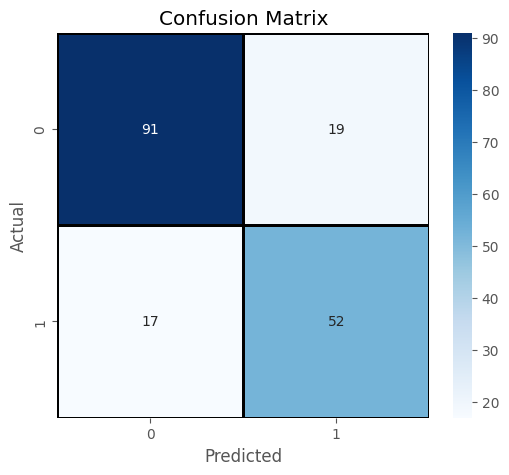

In [55]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [56]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [57]:
fpr,tpr,_ = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

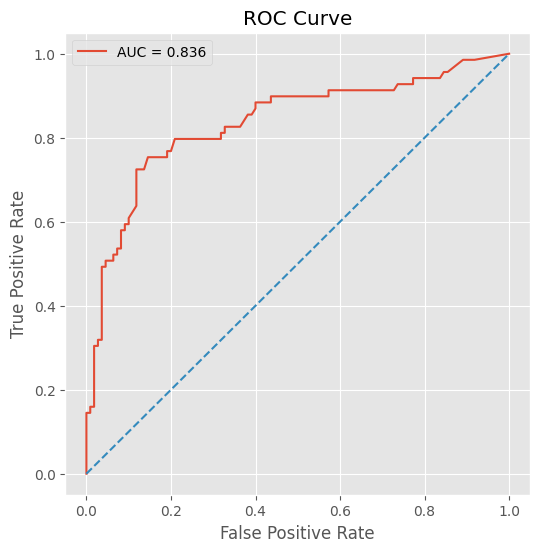

In [58]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [59]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

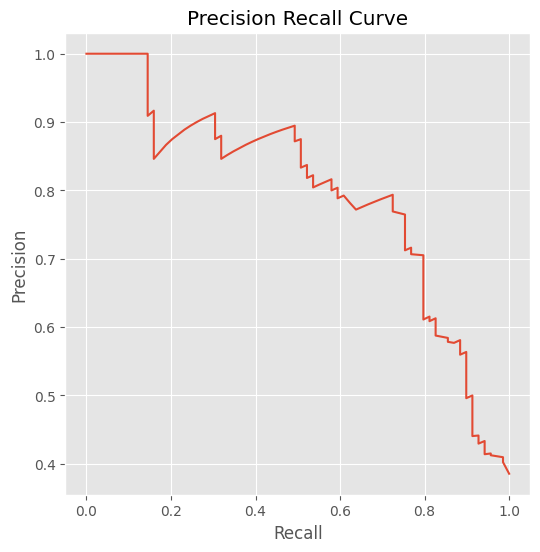

In [60]:
plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [61]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

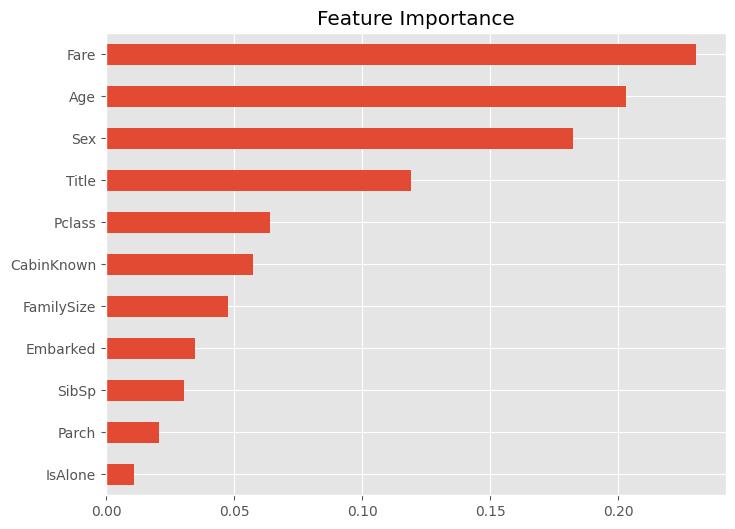

In [62]:
plt.figure(figsize=(8,6))

importance.plot.barh()

plt.title("Feature Importance")

plt.show()

In [63]:
params = {
    "n_estimators":[100,200,300],
    "max_depth":[3,5,7,None]
}

In [64]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7, None],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [65]:
grid.best_params_

{'max_depth': 3, 'n_estimators': 100}

In [66]:
grid.best_score_

np.float64(0.8230769230769232)

In [67]:
final_model = RandomForestClassifier(
    **grid.best_params_,
    random_state=42
)

final_model.fit(X,y)

RandomForestClassifier(max_depth=3, random_state=42)

In [68]:
submission = pd.DataFrame({

    "PassengerId":test_ids,

    "Survived":final_model.predict(test)

})

In [69]:
submission.head()

,PassengerId,Survived
0,892,0.0
1,893,1.0
2,894,0.0
3,895,0.0
4,896,1.0


In [70]:
submission.to_csv(
    "submission.csv",
    index=False
)





print("Submission File Saved Successfully!")

Submission File Saved Successfully!
